In [1]:
from numpy.random import beta
import torch.nn as nn
import torch
import numpy as np
import random
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, scale
import allel
from tqdm import tqdm

In [2]:
def load_vcf(file_path) -> dict:
    '''
    Converts a VCF file to an unphased genotype tensor.
    
    :param file_path: Path to the VCF file
    '''
    # Load VCF file using scikit-allel
    callset = allel.read_vcf(file_path, fields=['samples', 'calldata/GT', 'variants/CHROM', 'variants/POS', 'variants/REF', 'variants/ALT'])

    return callset

def create_unphased_tensor(callset: dict) -> torch.Tensor:
    '''
    Converts the genotype data from the callset to an unphased tensor.
    
    :param callset: Dictionary containing VCF data loaded by scikit-allel
    :return: Unphased genotype tensor of shape (variants, samples)
    '''
    # Extract genotype data and convert to a PyTorch tensor
    gt_array = callset['calldata/GT']  
    gt_tensor = torch.from_numpy(gt_array)  
    
    # Convert to unphased format by summing the two alleles for each sample and variant
    # Condition to handle missing data (-1) by setting the sum to -1 if either allele is missing
    # Else sum the two alleles to get the total count of alternate alleles (0, 1, or 2)
    unphased_tensor = torch.where(
        (gt_tensor[:, :, 0] == -1) | (gt_tensor[:, :, 1] == -1),
        -1,
        gt_tensor[:, :, 0] + gt_tensor[:, :, 1]
    ).to(torch.int)  # Convert to integer type
    
    unphsdr_tensor = torch.transpose(unphased_tensor, 1, 0)  # Transpose to shape (variants, samples)
    
    return unphsdr_tensor

In [11]:
# Try running on a small subset of SNPs first to test the model and then scale up to the full dataset.
# Also try to see if SNP loadings could be used to identify which SNPs are most important for the latent space representation and then focus on those SNPs for training the model. 
# This could help reduce the dimensionality of the input data and make training more efficient.

GENOTYPES = 3

class Genomic_VAE_1DCNN(nn.Module):
    def __init__(self, input_dim, encoder_hidden_dims, latent_dim, decoder_hidden_dims, activation=nn.ReLU(), n_classes=GENOTYPES):
        super(Genomic_VAE_1DCNN, self).__init__()
        self.input_dim = input_dim
        self.n_classes = n_classes  # Number of genotype classes (0, 1, 2)

        # 1D CNN Encoder for efficient feature extraction from long sequences.
        # Designed for very high-dimensional input (~450K SNP features).
        # Large strides in early layers are critical to reduce intermediate feature map
        # sizes and avoid excessive memory usage.
        # For input_dim = 450,000:
        #   Layer 1 Conv (stride=8):  450,000 → 56,250   | mem ~58 MB/batch-of-8
        #   MaxPool (stride=4):        56,250 → 14,062
        #   Layer 2 Conv (stride=4):  14,062 →  3,516
        #   MaxPool (stride=4):        3,516 →    879
        #   Layer 3 Conv (stride=4):    879 →    220
        #   AdaptiveAvgPool → 16                          | fixed 2048 output
        self.cnn_encoder = nn.Sequential(
            nn.Conv1d(1, 32, kernel_size=9, stride=8, padding=4),   # ~450K → ~56,250
            # nn.Conv1d(1, 32, kernel_size=18, stride=17, padding=9), 
            # nn.Conv1d(1, 32, kernel_size=36, stride=35, padding=18), 
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),                   # ~56,250 → ~14,062
            # nn.MaxPool1d(kernel_size=8, stride=4),
            # nn.MaxPool1d(kernel_size=16, stride=4),
            nn.Conv1d(32, 64, kernel_size=9, stride=4, padding=4),  # ~14,062 → ~3,516
            # nn.Conv1d(32, 64, kernel_size=18, stride=4, padding=9),
            # nn.Conv1d(32, 64, kernel_size=36, stride=4, padding=18),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(kernel_size=4, stride=4),                   # ~3,516 → ~879
            # nn.MaxPool1d(kernel_size=8, stride=4),
            # nn.MaxPool1d(kernel_size=16, stride=4),
            nn.Conv1d(64, 128, kernel_size=9, stride=4, padding=4), # ~879 → ~220
            # nn.Conv1d(64, 128, kernel_size=18, stride=4, padding=9),
            # nn.Conv1d(64, 128, kernel_size=36, stride=4, padding=18),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(16),                                # → (batch, 128, 16) fixed
        )
        # Fixed CNN output dimension regardless of input_dim (due to AdaptiveAvgPool1d)
        self.cnn_output_dim = 128 * 16  # 2048

        # Fully connected layers after CNN (Encoder)
        fc_layers = []
        prev_dim = self.cnn_output_dim
        for hidden_dim in encoder_hidden_dims:
            fc_layers.append(nn.Linear(prev_dim, hidden_dim))
            fc_layers.append(activation)
            prev_dim = hidden_dim
        self.fc_encoder = nn.Sequential(*fc_layers)

        # Latent space parameters
        self.mu = nn.Linear(encoder_hidden_dims[-1], latent_dim)
        self.logvar = nn.Linear(encoder_hidden_dims[-1], latent_dim)

        # Decoder FC stem: latent -> compact sequence embedding
        decoder_fc_layers = []
        prev_dim = latent_dim
        for hidden_dim in decoder_hidden_dims:
            decoder_fc_layers.append(nn.Linear(prev_dim, hidden_dim))
            decoder_fc_layers.append(activation)
            prev_dim = hidden_dim
        decoder_fc_layers.append(nn.Linear(prev_dim, self.cnn_output_dim))
        decoder_fc_layers.append(activation)
        self.decoder_fc = nn.Sequential(*decoder_fc_layers)

        # Decoder CNN head: progressively upsample from compact sequence → original SNP length.
        # ConvTranspose1d(kernel=16, stride=8, padding=4) gives exact 8x upsampling:
        #   output = (L_in - 1) * 8 - 8 + 16 = L_in * 8
        #   16 → 128 → 1024 → 8192 → Upsample(input_dim)
        # Final Upsample bridges ~8K → 450K (factor ~55x), which is far more reasonable
        # than the previous single jump of 128 → 450K (factor ~3,500x).
        self.decoder_cnn = nn.Sequential(
            nn.ConvTranspose1d(128, 64, kernel_size=16, stride=8, padding=4),  # 16 → 128
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.ConvTranspose1d(64, 32, kernel_size=16, stride=8, padding=4),   # 128 → 1,024
            nn.BatchNorm1d(32),
            nn.ReLU(),
            nn.ConvTranspose1d(32, 16, kernel_size=16, stride=8, padding=4),   # 1,024 → 8,192
            nn.BatchNorm1d(16),
            nn.ReLU(),
            nn.Upsample(size=self.input_dim, mode='linear', align_corners=False),  # 8,192 → input_dim
            nn.Conv1d(16, self.n_classes, kernel_size=1),                           # channel projection → n_classes
        )

    def decode_logits(self, z):
        decoded_fc = self.decoder_fc(z)  # (batch, 2048)
        decoded_seq = decoded_fc.view(z.size(0), 128, 16)  # (batch, 128, 16)
        logits_cnn = self.decoder_cnn(decoded_seq)  # (batch, n_classes, input_dim)
        logits = logits_cnn.permute(0, 2, 1).contiguous()  # (batch, input_dim, n_classes)
        return logits

    def forward(self, x):
        # x: (batch, input_dim)
        # Reshape for CNN: (batch, 1, input_dim)
        if x.dim() == 2:
            x = x.unsqueeze(1)
        encoded_cnn = self.cnn_encoder(x)  # (batch, 128, 16)
        encoded_flat = encoded_cnn.view(x.size(0), -1)  # (batch, 2048)
        encoded = self.fc_encoder(encoded_flat)
        mu = self.mu(encoded)
        logvar = self.logvar(encoded)
        z = self.reparameterize(mu, logvar)
        logits = self.decode_logits(z)
        return logits, mu, logvar

    # ? Not sure what this does
    def reparameterize(self, mu, logvar):
        """
        Reparameterization trick for sampling from N(mu, var) in a differentiable way.

        Args:
            mu (Tensor): shape (batch, latent_dim) - mean of the approximate posterior.
            logvar (Tensor): shape (batch, latent_dim) - log variance of the approximate posterior.

        Returns:
            Tensor: sampled latent `z` with shape (batch, latent_dim), computed as
            z = mu + sigma * eps where sigma = exp(0.5 * logvar) and eps ~ N(0, I).
        """
        assert mu.shape == logvar.shape, "mu and logvar must have the same shape"
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    # ? Not sure what this does
    def generate_data(self, N):
        """Generate N samples by sampling from N(0, I) and decoding to class logits.
        Returns integer class predictions (0, 1, 2) for each SNP.
        """
        self.eval()
        with torch.no_grad():
            z = torch.randn(N, self.mu.out_features)
            logits = self.decode_logits(z)
            # Sample from softmax distribution or take argmax
            probs = torch.softmax(logits, dim=-1)  # shape: (N, input_dim, 3)
            # Sample from categorical distribution
            generated_data = torch.multinomial(probs.view(-1, self.n_classes), num_samples=1).view(N, self.input_dim)
        return generated_data.cpu().numpy()

import torch
import torch.nn as nn

def VariationalLoss(logits, x, mu, logvar, beta=1e-1, gamma_maf=1e1, gamma_hwe=1e2):
    """
    Compute VAE loss with categorical cross-entropy, MAF agreement, and HWE prior.
    
    Args:
        logits (Tensor): shape (batch, input_dim, n_classes) - decoder output logits
        x (Tensor): shape (batch, input_dim) - target integer classes (0, 1, 2, or -1 for missing)
        mu (Tensor): encoder mean
        logvar (Tensor): encoder log-variance
        beta (float): weight for KL divergence
        gamma_maf (float): weight for Allele Frequency penalty
        gamma_hwe (float): weight for Hardy-Weinberg Equilibrium penalty
    """
    batch_size = logits.shape[0]
    input_dim = logits.shape[1]
    
    # ---------------------------------------------------------
    # 1. Standard VAE Losses (Reconstruction & KL)
    # ---------------------------------------------------------
    logits_flat = logits.view(-1, logits.shape[2])  # (batch*input_dim, n_classes)
    x_flat = x.long().view(-1)  # (batch*input_dim,)
    
    recon_loss = nn.CrossEntropyLoss(reduction='mean', ignore_index=-1)(logits_flat, x_flat)
    
    std_norm_mean = 0
    std_norm_var = 1.0
    # Note: Using mean() instead of sum() for KL is often more stable, 
    # but I have kept your sum() logic to preserve your current tuning.
    kl_loss = -0.5 * torch.sum(logvar + (std_norm_mean - mu.pow(2)) + (std_norm_var - logvar.exp())) 
    # To normalize by batch size, you might want: kl_loss = kl_loss / batch_size

    # ---------------------------------------------------------
    # Biological Constraints Setup (Differentiable)
    # ---------------------------------------------------------
    # Convert logits to probabilities: shape (batch, input_dim, 3)
    probs = torch.softmax(logits, dim=-1) 
    
    # Create a mask for valid genotypes (ignore -1)
    mask = (x != -1).float() # (batch, input_dim)
    valid_counts = mask.sum(dim=0) + 1e-8 # Prevent division by zero
    
    # ---------------------------------------------------------
    # 2. MAF / Allele Frequency Agreement Loss
    # ---------------------------------------------------------
    # Real Allele Frequency: sum(genotypes) / (2 * N)
    x_safe = torch.clamp(x, min=0).float() # Treat -1 as 0 temporarily (mask handles it)
    real_af = (x_safe * mask).sum(dim=0) / (2.0 * valid_counts)
    
    # Synthetic expected AF: E[g] = 0*P(0) + 1*P(1) + 2*P(2)
    expected_g = probs[:, :, 1] + 2.0 * probs[:, :, 2]
    syn_af = (expected_g * mask).sum(dim=0) / (2.0 * valid_counts)
    
    # MSE between synthetic and real allele frequencies per SNP
    maf_loss = torch.mean((syn_af - real_af)**2)

    # ---------------------------------------------------------
    # 3. Hardy-Weinberg Equilibrium (HWE) Loss
    # ---------------------------------------------------------
    # Based on the synthetic AF, what *should* the proportions be?
    hwe_p0 = (1.0 - syn_af)**2
    hwe_p1 = 2.0 * syn_af * (1.0 - syn_af)
    hwe_p2 = syn_af**2
    
    # What are the actual average probabilities generated by the model?
    mean_p0 = (probs[:, :, 0] * mask).sum(dim=0) / valid_counts
    mean_p1 = (probs[:, :, 1] * mask).sum(dim=0) / valid_counts
    mean_p2 = (probs[:, :, 2] * mask).sum(dim=0) / valid_counts
    
    # Penalize deviation from HWE expected proportions
    hwe_loss = torch.mean((mean_p0 - hwe_p0)**2 + 
                          (mean_p1 - hwe_p1)**2 + 
                          (mean_p2 - hwe_p2)**2)

    # ---------------------------------------------------------
    # Final Loss Combination
    # ---------------------------------------------------------
    total_loss = recon_loss + (beta * kl_loss) + (gamma_maf * maf_loss) + (gamma_hwe * hwe_loss)
    
    return total_loss, recon_loss, beta * kl_loss, gamma_maf * maf_loss, gamma_hwe * hwe_loss

def TrainModel(model, input_data, num_epochs=200, batch_size=8, save_path="best_vae_model.pth", patience=15):
    """
    Trains the VAE model with GPU acceleration, Early Stopping, and detailed loss tracking.
    
    Returns:
        model: The trained model.
        batch_losses: A dictionary containing lists of component losses recorded every 10 batches.
    """
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    print(f"Initialized training on device: {device}")
    
    model = model.to(device)

    X_train_tensor = torch.tensor(input_data, dtype=torch.long)
    y_train_tensor = torch.tensor(input_data, dtype=torch.long)
    ds = torch.utils.data.TensorDataset(X_train_tensor, y_train_tensor)
    dl = torch.utils.data.DataLoader(ds, batch_size=batch_size, shuffle=True)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.001)
    loss_fx = VariationalLoss

    training_loss = []
    best_loss = float('inf')  
    epochs_no_improve = 0  
    
    # NEW: Dictionary to store losses every 10 batches
    batch_losses = {
        'total': [],
        'recon': [],
        'kl': [],
        'maf': [],
        'hwe': []
    }
    
    global_batch_idx = 0 # To track total batches processed across all epochs

    for epoch in range(num_epochs):
        model.train() 
        total_epoch_loss = 0 
        
        progress_bar = tqdm(dl, desc=f"Epoch {epoch+1}/{num_epochs}", leave=False)
        
        for batch_idx, (batch_x, batch_y) in enumerate(progress_bar):
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            batch_x_float = batch_x.float()
            optimizer.zero_grad() 
            
            logits, mu, logvar = model(batch_x_float) 
            
            # Unpack the 5 loss components returned by the updated VariationalLoss
            loss, recon_loss, kl_loss, maf_loss, hwe_loss = loss_fx(logits, batch_y, mu, logvar)  
            
            loss.backward()
            optimizer.step()
            
            total_epoch_loss += loss.item()
            
            # NEW: Record losses every 10 batches
            if global_batch_idx % 10 == 0:
                batch_losses['total'].append(loss.item())
                batch_losses['recon'].append(recon_loss.item())
                batch_losses['kl'].append(kl_loss.item())
                batch_losses['maf'].append(maf_loss.item())
                batch_losses['hwe'].append(hwe_loss.item())
                
            global_batch_idx += 1
            
            # Update progress bar
            progress_bar.set_postfix({
                'tot': f"{loss.item():.2f}", 
                'rec': f"{recon_loss.item():.2f}", 
                'kl': f"{kl_loss.item():.2f}",
                'maf': f"{maf_loss.item():.4f}",
                'hwe': f"{hwe_loss.item():.4f}"
            })

        avg_epoch_loss = total_epoch_loss / len(dl)
        training_loss.append(avg_epoch_loss)
        
        # --- EARLY STOPPING & CHECKPOINT LOGIC ---
        if avg_epoch_loss < best_loss:
            best_loss = avg_epoch_loss
            epochs_no_improve = 0  
            torch.save(model.state_dict(), save_path)
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_epoch_loss:.4f} --> Best model saved!")
        else:
            epochs_no_improve += 1 
            print(f"Epoch {epoch+1}/{num_epochs}, Loss: {avg_epoch_loss:.4f} (No improvement: {epochs_no_improve})")

        if epochs_no_improve >= patience:
            print(f"\n🛑 Early stopping triggered at epoch {epoch+1}.")
            break 
        # -----------------------------------------

    print(f"\nTraining complete. Overall best loss achieved: {best_loss:.4f}")

    # Plot the epoch-level training loss
    plt.figure(figsize=(8,5))
    plt.plot(training_loss, label='Total Epoch Loss', color='black')
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title("Epoch-level Training Loss")
    plt.legend()
    plt.show()
    
    return model, batch_losses

In [4]:
pop = 'CLM'
# file_path = '/home/nba9/CSE7850/CSE-7850_Experiments/exp1_CLM.vcf.gz'
# file_path = '/home/nba9/CSE7850/CSE-7850_Experiments/exp2_PUR.vcf.gz'
# file_path = '/home/nba9/CSE7850/CSE-7850_Experiments/exp3_ACB.vcf.gz'
# file_path = '/home/nba9/CSE7850/CSE-7850_Experiments/exp4_JPT.vcf.gz'
# file_path = '/home/nba9/CSE7850/CSE-7850_Experiments/exp5_GIH.vcf.gz'
# vcf = load_vcf(file_path)
# tensor = create_unphased_tensor(vcf)
# Extract SNP gnomAD IDs
# vcf['variants/ALT'] = vcf['variants/ALT'][:, 0]  # Get the first alternate allele for each variant
# snp_ids = 'chr' + vcf['variants/CHROM'] + ':' + vcf['variants/POS'].astype(str) + ':' + vcf['variants/REF'] + ':' + vcf['variants/ALT']
# Convert tensor to NumPy array
# tensor_np = tensor.numpy()
# np.save(pop+"_unphased_tensor.npy", tensor_np)
tensor_np = np.load(pop+"_unphased_tensor.npy")
# Create a DataFrame with SNP IDs as columns
# input_data = pd.DataFrame(tensor_np, columns=snp_ids)
# input_data.head()
# input_data.to_csv(pop+"_unphased_tensor.csv", index=False)

In [12]:
# Create an instance of the Genomic_VAE
input_dim = tensor_np.shape[1]
encoder_hidden_dims = [1024, 512, 256, 128, 64, 32, 16 , 8, 4] # Decreasing hidden layer sizes for the encoder
latent_dim = 2  # Size of the latent space (bottleneck)
decoder_hidden_dims = [4, 8, 16, 32, 64, 128, 256, 512, 1024]  # Increasing hidden layer sizes for the decoder (mirroring the encoder)
n_classes = 3
model = Genomic_VAE_1DCNN(input_dim=input_dim, encoder_hidden_dims=encoder_hidden_dims, latent_dim=latent_dim, decoder_hidden_dims=decoder_hidden_dims, n_classes=n_classes)

Initialized training on device: cuda


Epoch 1/200, Loss: 2.3107 --> Best model saved!


Epoch 2/200, Loss: 1.0507 --> Best model saved!


Epoch 3/200, Loss: 0.7429 --> Best model saved!


Epoch 4/200, Loss: 0.6800 --> Best model saved!


...

Epoch 15/200, Loss: 0.6592 (No improvement: 2)


Epoch 16/200, Loss: 0.6589 --> Best model saved!


Epoch 17/200, Loss: 0.6595 (No improvement: 1)


Epoch 18/200, Loss: 0.6594 (No improvement: 2)


Epoch 19/200, Loss: 0.6591 (No improvement: 3)

🛑 Early stopping triggered at epoch 19.

Training complete. Overall best loss achieved: 0.6589


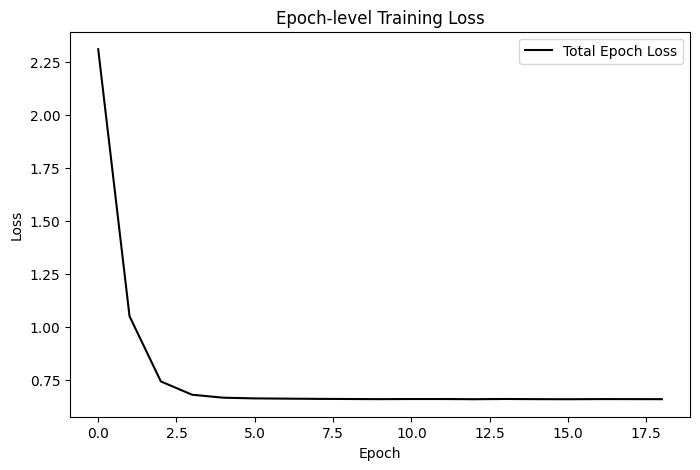

In [13]:
# Train the model
model, batch_losses = TrainModel(model, tensor_np, num_epochs=200, save_path=pop+"_best_vae_model_test_loss.pth", patience=3)

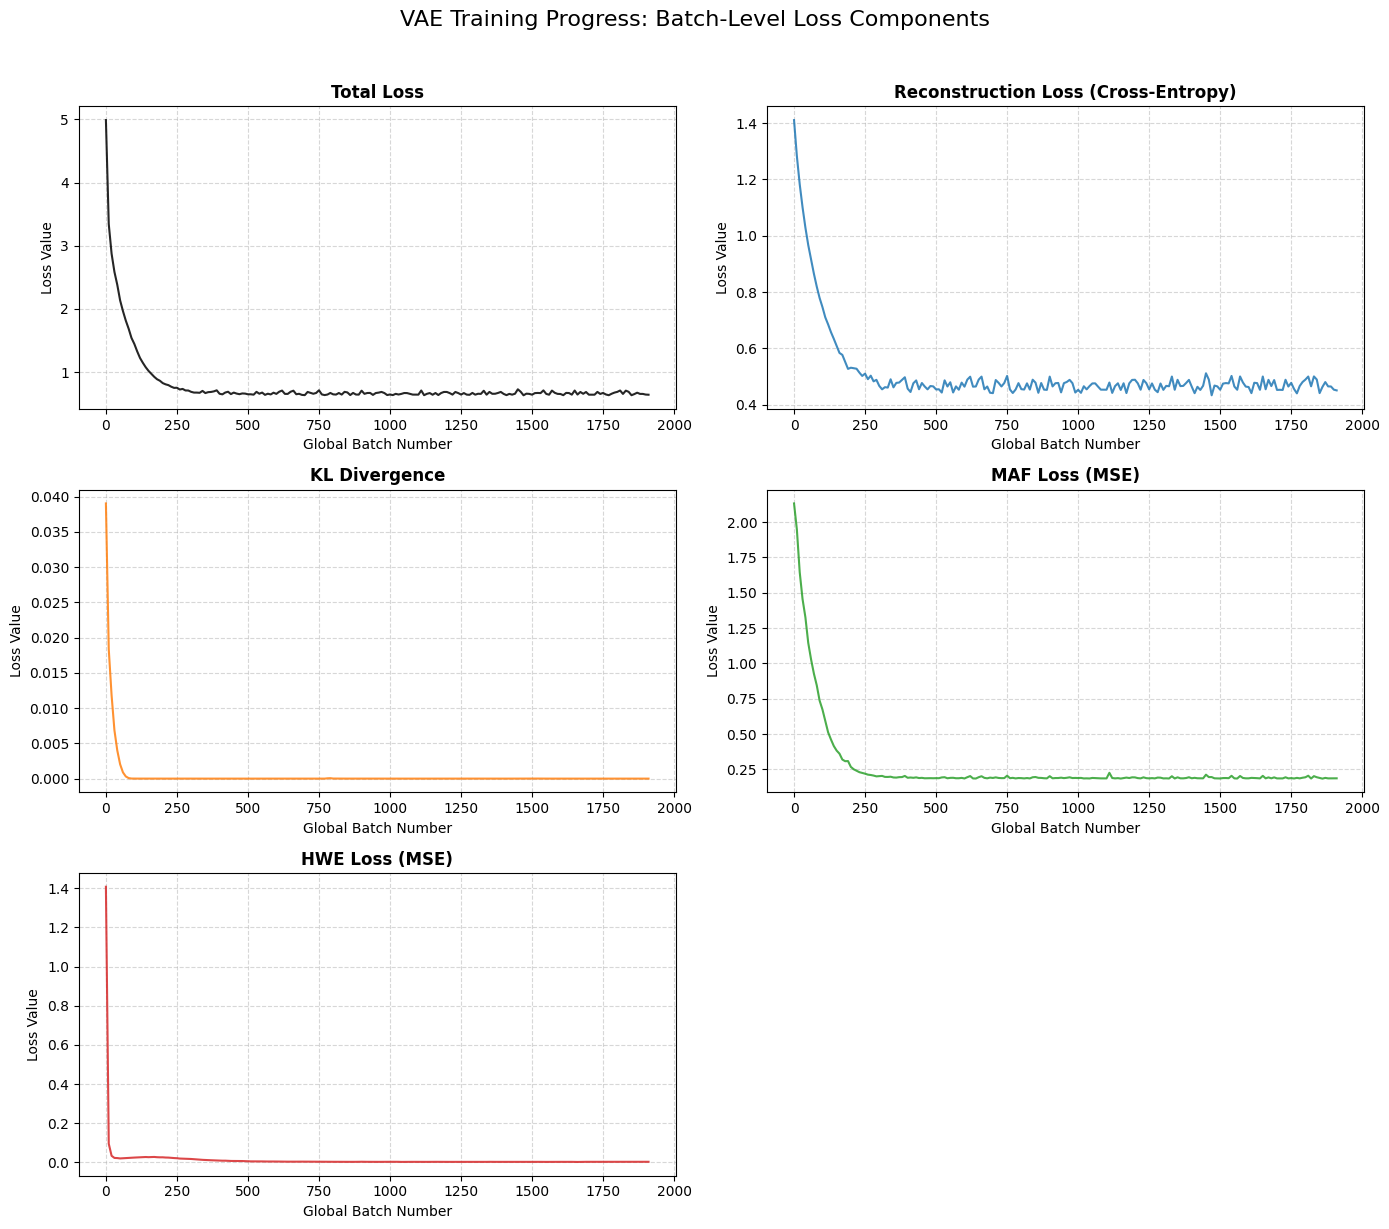

In [14]:
import matplotlib.pyplot as plt

def plot_batch_losses(batch_losses):
    """
    Plots the component losses recorded during training.
    Assumes batch_losses is a dictionary with keys: 'total', 'recon', 'kl', 'maf', 'hwe'.
    """
    # Create a 3x2 grid of subplots
    fig, axes = plt.subplots(3, 2, figsize=(14, 12))
    axes = axes.flatten() # Flatten to easily iterate over them
    
    # Define plotting configurations
    loss_keys = ['total', 'recon', 'kl', 'maf', 'hwe']
    titles = ['Total Loss', 'Reconstruction Loss (Cross-Entropy)', 
              'KL Divergence', 'MAF Loss (MSE)', 'HWE Loss (MSE)']
    colors = ['black', '#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']
    
    # Iterate through the dictionary and plot each loss on its own panel
    for i, (key, title, color) in enumerate(zip(loss_keys, titles, colors)):
        ax = axes[i]
        
        # We multiply by 10 because you saved the loss every 10 batches
        x_axis = [x * 10 for x in range(len(batch_losses[key]))]
        
        ax.plot(x_axis, batch_losses[key], color=color, alpha=0.85, linewidth=1.5)
        ax.set_title(title, fontsize=12, fontweight='bold')
        ax.set_xlabel('Global Batch Number')
        ax.set_ylabel('Loss Value')
        ax.grid(True, linestyle='--', alpha=0.5)
        
    # Remove the 6th empty subplot (since we only have 5 losses)
    fig.delaxes(axes[5])
    
    plt.suptitle("VAE Training Progress: Batch-Level Loss Components", fontsize=16, y=1.02)
    plt.tight_layout()
    plt.show()

# Example of how to call it after TrainModel finishes:
# model, batch_losses = TrainModel(...)
plot_batch_losses(batch_losses)

In [15]:
device = torch.device("cpu")
# CHECKPOINT_PATH = pop+"_best_vae_model.pth"
# CHECKPOINT_PATH = pop+"_best_vae_model_4xkernelsize.pth"
CHECKPOINT_PATH = pop+"_best_vae_model_test_loss.pth"
try:
    model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device, weights_only=True))
    print(f"✅ Successfully loaded model weights from '{CHECKPOINT_PATH}'")
except FileNotFoundError:
    print(f"❌ Error: Could not find '{CHECKPOINT_PATH}'. Did the training loop finish and save it?")
    exit()
model = model.to(device)
model.eval()

✅ Successfully loaded model weights from 'CLM_best_vae_model_test_loss.pth'


Genomic_VAE_1DCNN(
  (cnn_encoder): Sequential(
    (0): Conv1d(1, 32, kernel_size=(9,), stride=(8,), padding=(4,))
    (1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU()
    (3): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (4): Conv1d(32, 64, kernel_size=(9,), stride=(4,), padding=(4,))
    (5): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU()
    (7): MaxPool1d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
    (8): Conv1d(64, 128, kernel_size=(9,), stride=(4,), padding=(4,))
    (9): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU()
    (11): AdaptiveAvgPool1d(output_size=16)
  )
  (fc_encoder): Sequential(
    (0): Linear(in_features=2048, out_features=1024, bias=True)
    (1): ReLU()
    (2): Linear(in_features=1024, out_features=512, bias=True)
    (3): ReLU()
    (4): Linear(in_featur

In [8]:
# --- Generate Synthetic Genotypes ---
NUM_SYNTHETIC_SAMPLES = 100
print(f"🧬 Generating {NUM_SYNTHETIC_SAMPLES} synthetic individuals...")
synthetic_data = model.generate_data(NUM_SYNTHETIC_SAMPLES)
print(f"✅ Generation complete!")
print(f"Output Data Type: {type(synthetic_data)}")
print(f"Output Shape: {synthetic_data.shape} -> (Individuals, SNPs)")
print(f"Sample Data (First 10 SNPs of Individual 1): {synthetic_data[0][:10]}")
# Save the generated synthetic data to disk for downstream GWAS/PLINK analysis
# np.save(pop+"_generated_data.npy", synthetic_data)
# np.save(pop+"_generated_data_4xkernelsize.npy", synthetic_data)
np.save(pop+"_generated_data_test_loss.npy", synthetic_data)
# synthetic_data_df = pd.DataFrame(synthetic_data, columns=columns)
# synthetic_data_df.to_csv(pop+"_generated_data.csv", index=False)
print(f"💾 Saved synthetic data to '{pop}_generated_data_test_loss.npy'")

🧬 Generating 100 synthetic individuals...
✅ Generation complete!
Output Data Type: <class 'numpy.ndarray'>
Output Shape: (100, 1348120) -> (Individuals, SNPs)
Sample Data (First 10 SNPs of Individual 1): [1 0 0 0 0 0 1 0 0 0]
💾 Saved synthetic data to 'CLM_generated_data_4xkernelsize.npy'


Scaling data...
Running PCA...


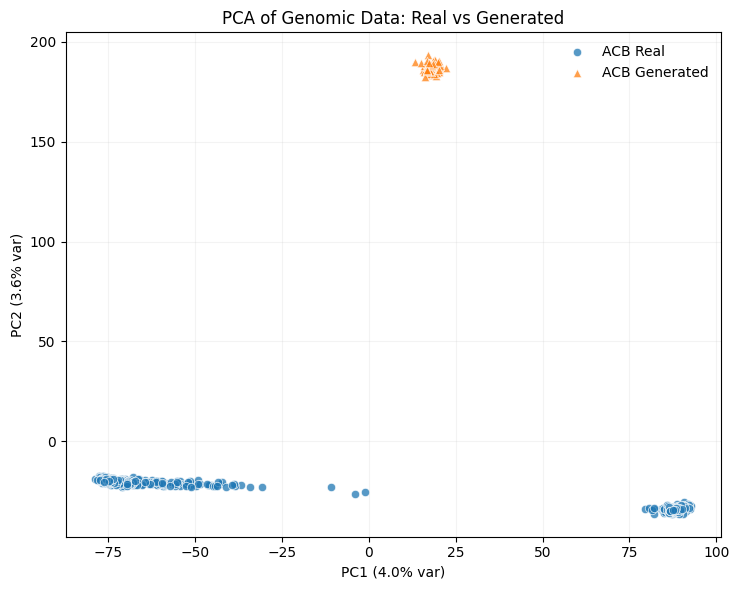

In [1]:
import pandas as pd
import numpy as np
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# --- 1 & 2) Read data and immediately convert to NumPy arrays ---
# Note: pd.read_csv is still used here because its C-engine is generally 
# faster at parsing large CSVs than numpy's native text loaders.
pop = "ACB"
arr1 = np.load(pop+"_unphased_tensor.npy")
arr2 = np.load(pop+"_generated_data.npy")
input_dim = arr1.shape[1]
num_snps_subset = 135000
rng = np.random.default_rng(seed=2) # CLM: 0, PUR: 1, ACB: 2, JLP: 3, GIH: 4
choices = rng.choice(np.arange(input_dim), size=num_snps_subset)
arr1 = arr1[:,choices]
arr2 = arr2[:,choices]
np.save(pop+"_unphased_tensor_subset_snps.npy",arr1)
np.save(pop+"_generated_data_subset_snps.npy",arr2)

# --- 3) Stack samples using pure NumPy ---
X = np.vstack((arr1, arr2))
labels = np.array([0] * len(arr1) + [1] * len(arr2))  # 0=file1, 1=file2

# --- 4) Scale features ---
print("Scaling data...")
X_scaled = StandardScaler().fit_transform(X)

# --- 5) Run PCA with randomized solver for massive speedup ---
print("Running PCA...")
# svd_solver='randomized' is the key change here for genomic-scale data
pca = PCA(n_components=2, svd_solver='randomized', random_state=0)
PC = pca.fit_transform(X_scaled)
evr = pca.explained_variance_ratio_

# --- 6) Plot with different colors/markers for each file ---
plt.figure(figsize=(7.5, 6))
plt.scatter(PC[labels == 0, 0], PC[labels == 0, 1],
            c="#1f77b4", marker="o", alpha=0.75, edgecolor="white", linewidth=0.6, label=pop+" Real")
plt.scatter(PC[labels == 1, 0], PC[labels == 1, 1],
            c="#ff7f0e", marker="^", alpha=0.75, edgecolor="white", linewidth=0.6, label=pop+" Generated")

plt.xlabel(f"PC1 ({evr[0]*100:.1f}% var)")
plt.ylabel(f"PC2 ({evr[1]*100:.1f}% var)")
plt.title("PCA of Genomic Data: Real vs Generated")
plt.legend(frameon=False)
plt.grid(alpha=0.15)
plt.tight_layout()

# Save plot before showing
plt.savefig(pop+"_pca_real_vs_synthetic.png", dpi=300, bbox_inches="tight")
plt.show()

# --- 7) Save results efficiently ---
# Reconstruct a small dataframe just for the output 
output_df = pd.DataFrame(PC, columns=["PC1", "PC2"])
output_df["source"] = np.where(labels == 0, pop+"_real", pop+"_synthetic")
output_df.to_csv(pop+"_pca_scores_real_vs_synthetic.csv", index=False)